# Integration_multiome_data

Integration of RNA and ATAC data with MOFA+ package

In [1]:
## Import libraries
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import anndata as ad
import snapatac2 as snap
import muon as mu
from muon import atac as ac
from mudata import MuData

In [33]:
## Setting verbosity and figure params
sc.settings.verbosity = 0 # show only error message
sc.settings.set_figure_params(
    dpi = 80,
facecolor = "white",
frameon = True,
)

In [34]:
## Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [35]:
## Load RNA data
rna = sc.read('/mnt/projects/labs/multiome_seq_data/RNA_downstream.h5ad')
## Load ATAC data 
atac = sc.read('/mnt/projects/labs/multiome_seq_data/atac_pre_processed_1.h5ad')

In [36]:
## Filter just the common cells
shared_barcodes = rna.obs.index.isin(atac.obs.index)
rna = rna[shared_barcodes].copy()
atac = atac[atac.obs.index.isin(rna.obs.index)].copy()

In [37]:
rna

AnnData object with n_obs × n_vars = 50038 × 26783
    obs: 'batch', 'sample', 'line', 'patient', 'condition', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'predicted_doublets', 'doublet_scores', 'barcode', 'Effectorness', 'Effector_cells', 'Cell_state', 'slec_non_eff', 'mpec_non_eff'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Cell_state_colors', 'Effector_cells_colors', 'condition_colors', 'hvg', 'line_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [38]:
atac

AnnData object with n_obs × n_vars = 50038 × 94408
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'batch', 'sample', 'line', 'condition', 'tsse', 'doublet_probability', 'doublet_score'
    var: 'count', 'selected'
    uns: 'doublet_rate', 'frag_size_distr', 'reference_sequences', 'scrublet_sim_doublet_score'
    obsm: 'fragment_paired'

In [39]:
## Add column Effector cells to atac data
atac.obs['Effector_cells'] = rna.obs['Effector_cells']
## Add column Cell_state to atac data
atac.obs['Cell_state'] = rna.obs['Cell_state']

In [41]:
## We use the same method for dimensionality reduction and batch correction for ATAC data as in the RNA_Pre-Processing notebook
## to ensure consistency for the integration

In [42]:
## Normalization
atac.X = atac.X.astype('float64')
sc.pp.normalize_per_cell(atac, counts_per_cell_after=1e4)
sc.pp.log1p(atac)

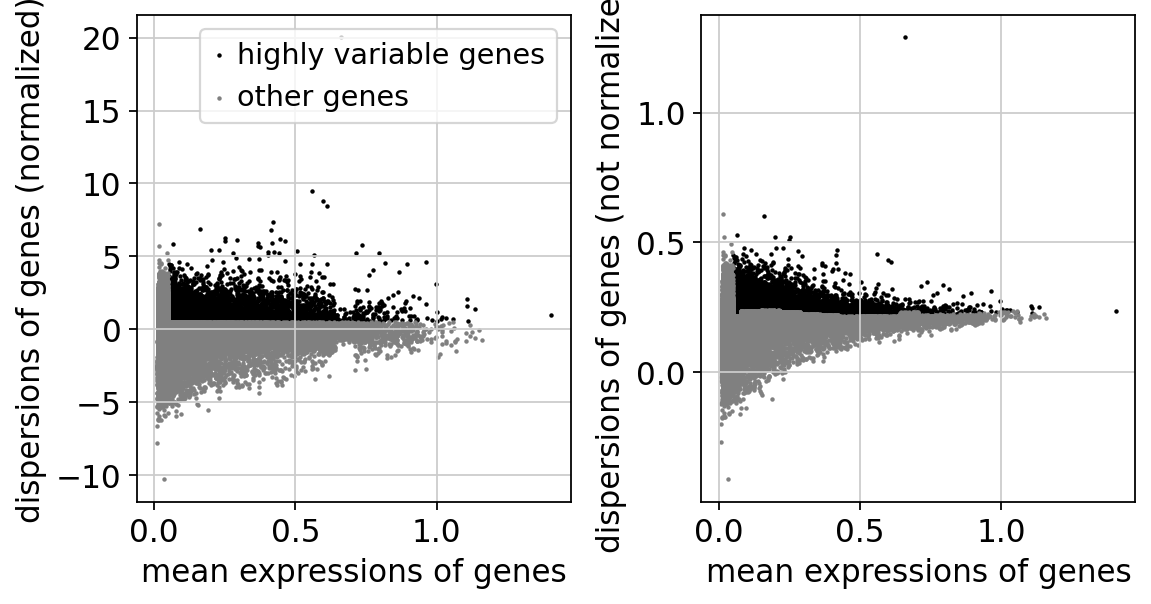

In [43]:
## Feature selection
sc.pp.highly_variable_genes(atac, min_mean=0.05, max_mean=1.5, min_disp=.5)
sc.pl.highly_variable_genes(atac)

In [44]:
np.sum(atac.var.highly_variable)

9330

In [45]:
## PCA
sc.pp.scale(atac, max_value=10)
sc.tl.pca(atac)

In [46]:
## Compute neighbors 
sc.pp.neighbors(atac, n_neighbors=50, n_pcs=50)

## UMAP
sc.tl.umap(atac, spread=1, min_dist=0.5,  random_state=2)

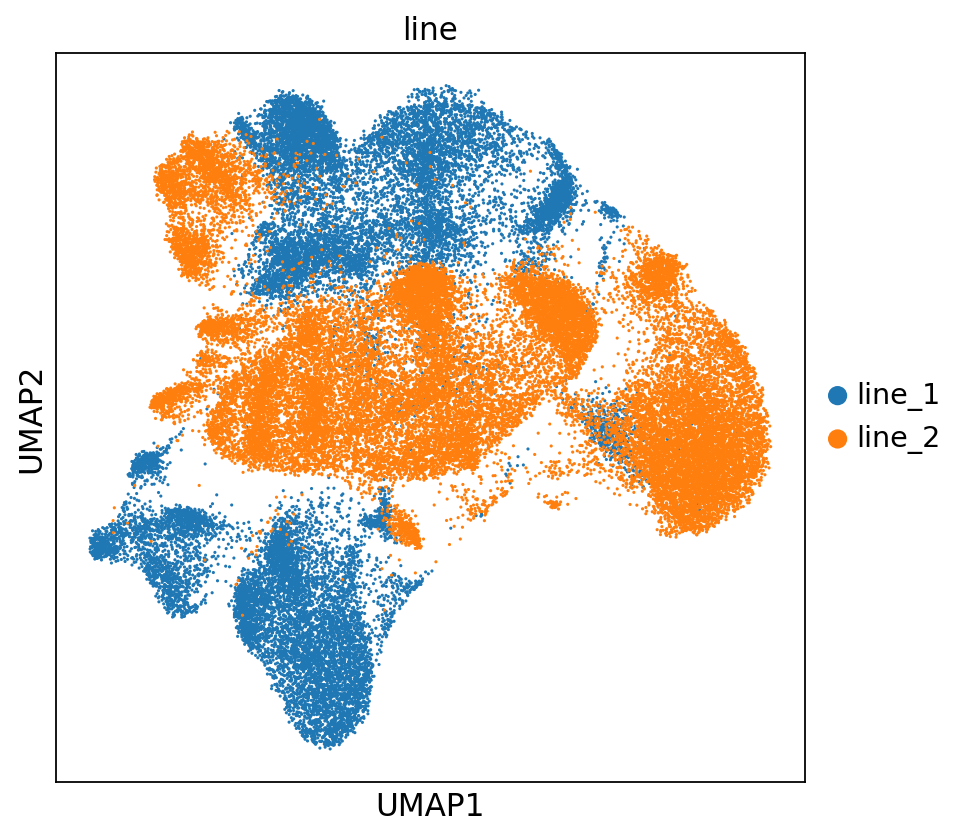

In [47]:
## UMAP line to investigate for batch correction
fig,ax = plt.subplots(figsize=(6,6))
ax = sc.pl.scatter(atac, basis = 'umap', color = 'line',size=8, ax=ax)
plt.show()

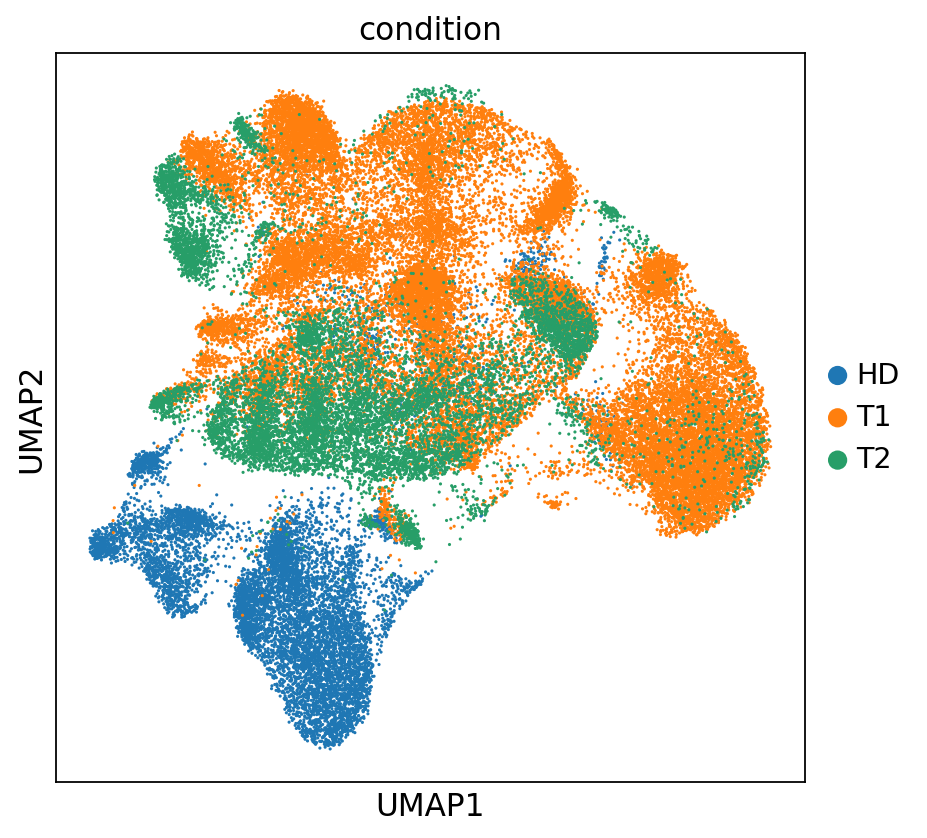

In [48]:
## UMAP condition to investigate for batch correction
fig,ax = plt.subplots(figsize=(6,6))
ax = sc.pl.scatter(atac, basis = 'umap', color = 'condition',size=8, ax=ax)
plt.show()


**Batch effect correction with harmony**

In [49]:
import scanpy.external as sce

In [50]:
## Compute data integration on line
sce.pp.harmony_integrate(atac, 'line')

2025-06-05 11:12:03,767 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-06-05 11:12:03 - INFO - Computing initial centroids with sklearn.KMeans...
2025-06-05 11:12:27,757 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-06-05 11:12:27 - INFO - sklearn.KMeans initialization complete.
2025-06-05 11:12:28,073 - harmonypy - INFO - Iteration 1 of 10
2025-06-05 11:12:28 - INFO - Iteration 1 of 10
2025-06-05 11:12:52,475 - harmonypy - INFO - Iteration 2 of 10
2025-06-05 11:12:52 - INFO - Iteration 2 of 10
2025-06-05 11:13:16,973 - harmonypy - INFO - Iteration 3 of 10
2025-06-05 11:13:16 - INFO - Iteration 3 of 10
2025-06-05 11:13:40,972 - harmonypy - INFO - Converged after 3 iterations
2025-06-05 11:13:40 - INFO - Converged after 3 iterations


In [51]:
'X_pca_harmony' in atac.obsm

True

In [52]:
## Compute neighbors on integrated data
sc.pp.neighbors(atac, n_neighbors=50, n_pcs=50,use_rep="X_pca_harmony")

In [53]:
## Compute UMAP on integrate data
sc.tl.umap(atac, spread=1, min_dist=0.5,  random_state=2)

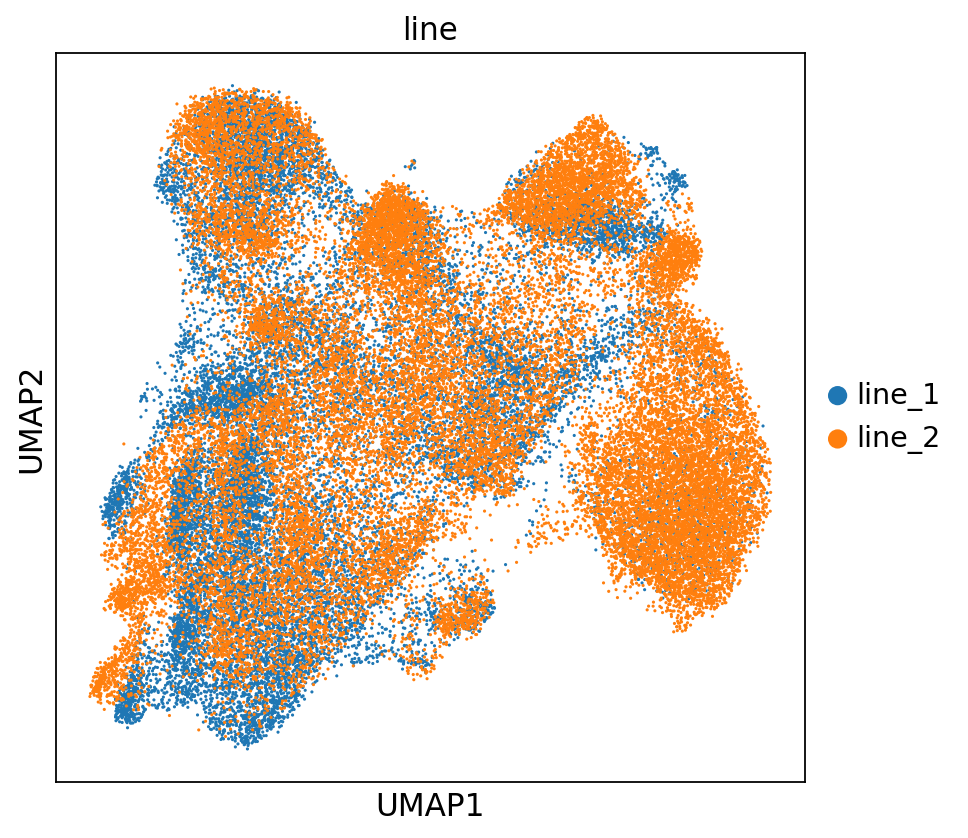

In [54]:
## Plot line after batch correction
fig,ax = plt.subplots(figsize=(6,6))
ax = sc.pl.scatter(atac, basis = 'umap', color = 'line',size=8, ax=ax)
plt.show()

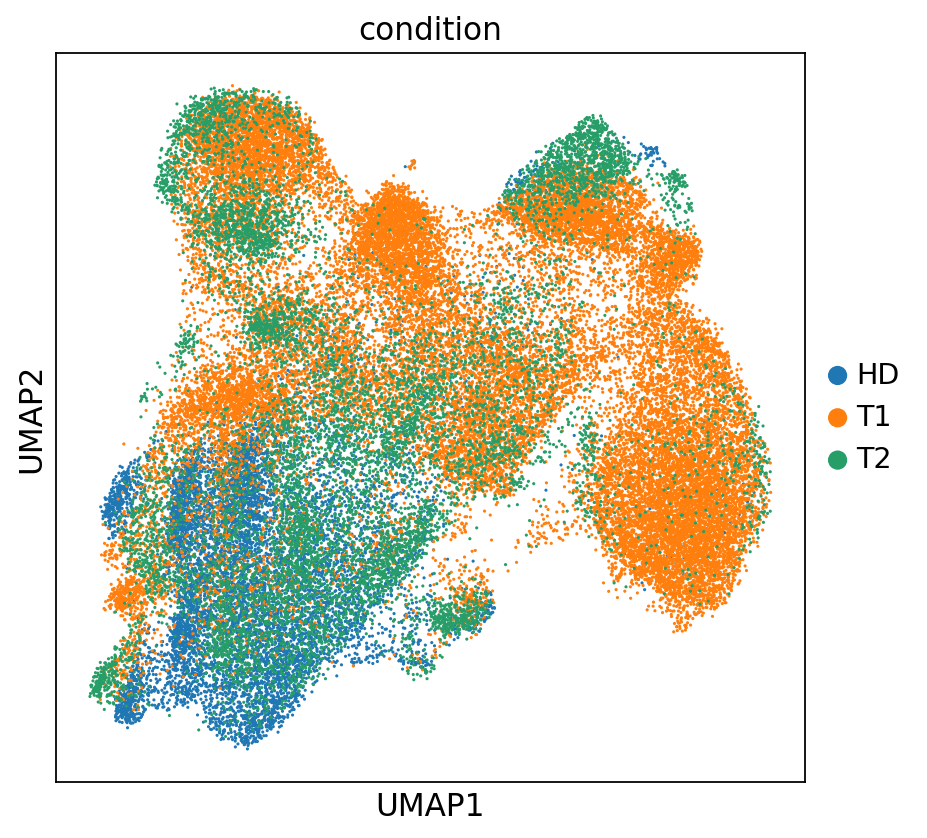

In [55]:
## Plot condition after batch correction
fig,ax = plt.subplots(figsize=(6,6))
ax = sc.pl.scatter(atac, basis = 'umap', color = 'condition',size=8, ax=ax)
plt.show()

**Integration scATAC data and scRNA data with MOFA+ package**

In [56]:
## Create a unique mudata with rna and atac
mdata = MuData({'RNA': rna, 'ATAC': atac})
mdata

MuData object with n_obs × n_vars = 50038 × 121191
  var:	'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
  2 modalities
    RNA:	50038 x 26783
      obs:	'batch', 'sample', 'line', 'patient', 'condition', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'predicted_doublets', 'doublet_scores', 'barcode', 'Effectorness', 'Effector_cells', 'Cell_state', 'slec_non_eff', 'mpec_non_eff'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'Cell_state_colors', 'Effector_cells_colors', 'condition_colors', 'hvg', 'line_colors', 'log1p', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'
    ATAC:	50038 x 94408
      obs:	'n_fragment', 'frac_dup', 'frac_mito', 'batch', 'sample', 'line', 'condition', 'tsse', 'doublet_probability', 'doublet_score', 'Effector_cells', 'Cell_state', 'n_counts'
      var:	'count', 'selected', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'doublet_rate', 'frag_size_distr', 'reference_sequences', 'scrublet_sim_doublet_score', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'line_colors', 'condition_colors'
      obsm:	'fragment_paired', 'X_pca', 'X_umap', 'X_pca_harmony'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'

In [57]:
## Create new AnnData objects with Harmony embeddings as .X
rna_harmony = ad.AnnData(X=mdata['RNA'].obsm['X_pca_harmony'])
atac_harmony = ad.AnnData(X=mdata['ATAC'].obsm['X_pca_harmony'])

In [58]:
## Paste the .obs
rna_harmony.obs = mdata['RNA'].obs.copy()
atac_harmony.obs = mdata['ATAC'].obs.copy()

In [59]:
## Create new mdata with harmony pca coordinates
mdata_harmony = mu.MuData({'RNA': rna_harmony, 'ATAC': atac_harmony})
mdata_harmony

MuData object with n_obs × n_vars = 50038 × 100
  2 modalities
    RNA:	50038 x 50
      obs:	'batch', 'sample', 'line', 'patient', 'condition', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'predicted_doublets', 'doublet_scores', 'barcode', 'Effectorness', 'Effector_cells', 'Cell_state', 'slec_non_eff', 'mpec_non_eff'
    ATAC:	50038 x 50
      obs:	'n_fragment', 'frac_dup', 'frac_mito', 'batch', 'sample', 'line', 'condition', 'tsse', 'doublet_probability', 'doublet_score', 'Effector_cells', 'Cell_state', 'n_counts'

In [60]:
## Run the model
mu.tl.mofa(mdata_harmony,n_factors=20, outfile="MOFA_integration.h5ad",gpu_mode=True)


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
       
 
        
Loaded view='RNA' group='group1' with N=50038 samples and D=50 features...
Loaded view='ATAC' group='group1' with N=50038 samples and D=50 features...


Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: Tru

In [61]:
## Compute neighbors and UMAPs the data modelled
sc.pp.neighbors(mdata_harmony, use_rep="X_mofa",)
sc.tl.umap(mdata_harmony, random_state=1)

In [62]:
mdata_harmony.obsm["X_mofa_umap"] = mdata_harmony.obsm["X_umap"]

... storing 'RNA:batch' as categorical
... storing 'RNA:sample' as categorical
... storing 'RNA:line' as categorical
... storing 'RNA:patient' as categorical
... storing 'RNA:condition' as categorical
... storing 'RNA:Effectorness' as categorical
... storing 'RNA:Effector_cells' as categorical
... storing 'RNA:Cell_state' as categorical
... storing 'RNA:slec_non_eff' as categorical
... storing 'RNA:mpec_non_eff' as categorical
... storing 'ATAC:batch' as categorical
... storing 'ATAC:sample' as categorical
... storing 'ATAC:line' as categorical
... storing 'ATAC:condition' as categorical
... storing 'ATAC:Effector_cells' as categorical
... storing 'ATAC:Cell_state' as categorical


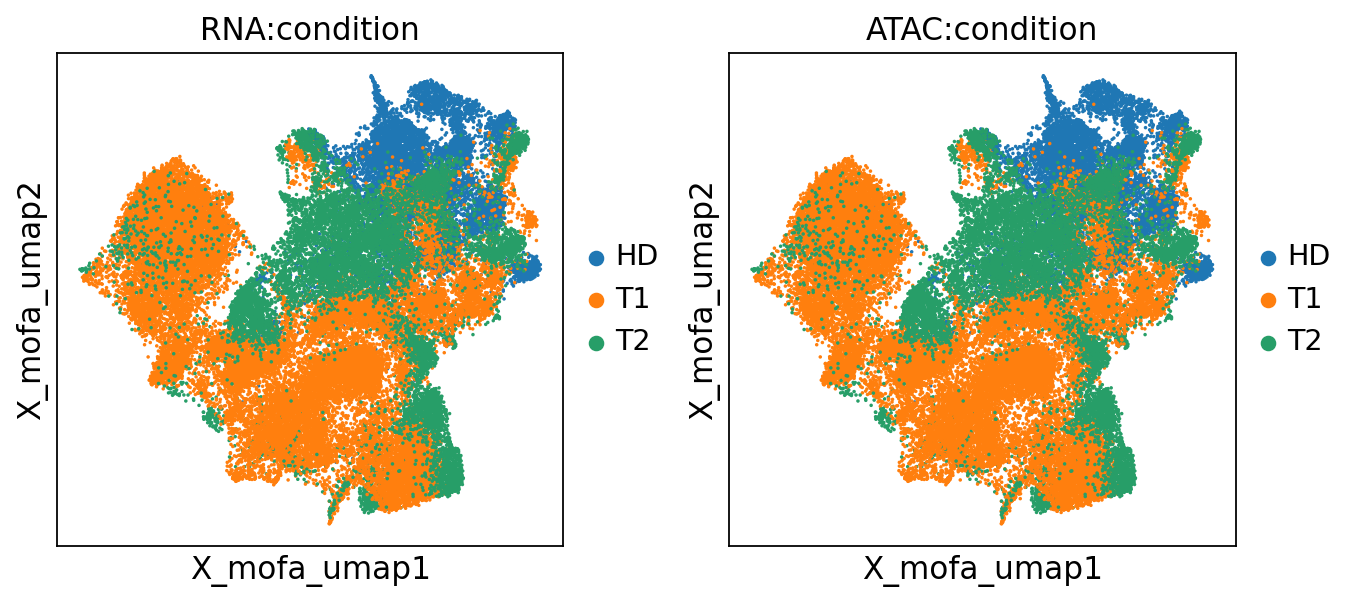

In [63]:
## Visualize the conditions in both ATAC and RNA
mu.pl.embedding(mdata_harmony, basis="X_mofa_umap", color=["RNA:condition", "ATAC:condition"], size=10)

In [64]:
## Save the new mudata trained on the MOFA+ model
mdata_harmony.write("/mnt/projects/labs/multiome_seq_data/mudata_MOFA_integrated_harmony.h5mu")